In [2]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = IR_df = pd.read_csv("C:/Users/Jesse/OneDrive/Desktop/QSS20_WI26/Final Project/ICERemovalsdata.csv",
                        encoding='latin-1')

In [9]:
print(df.head())

  Arresting Agency          Criminality Area of Responsibility (AOR)  \
0              CBP  Criminal Conviction                      Atlanta   
1              CBP  Criminal Conviction                      Atlanta   
2              CBP  Criminal Conviction                      Atlanta   
3              CBP  Criminal Conviction                      Atlanta   
4              CBP  Criminal Conviction                      Atlanta   

  Country of Citizenship  Fiscal Year  Fiscal Quarter  Fiscal Month  \
0            EL SALVADOR         2024               2             4   
1              GUATEMALA         2021               1             1   
2              GUATEMALA         2021               1             2   
3              GUATEMALA         2023               1             2   
4              GUATEMALA         2023               2             4   

  Month-Year  Removals  
0   Jan 2024        10  
1   Oct 2020        25  
2   Nov 2020        18  
3   Nov 2022        13  
4   Jan 2023   

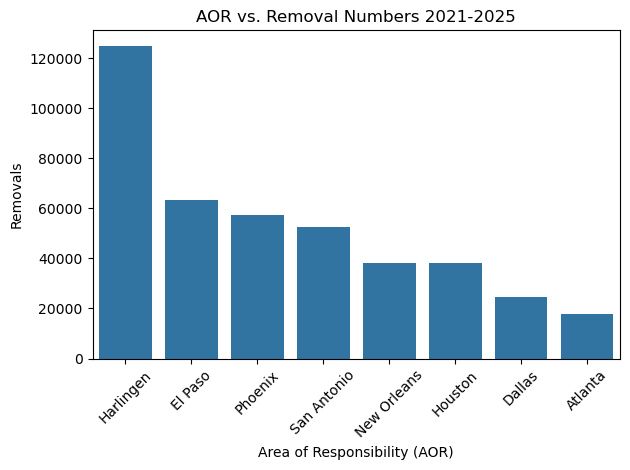

In [29]:
country_totals = df.groupby('Area of Responsibility (AOR)')['Removals'].sum().reset_index()
country_totals = country_totals.sort_values('Removals', ascending=False).head(8)

sns.barplot(data=country_totals, x='Area of Responsibility (AOR)', y='Removals')
plt.title('AOR vs. Removal Numbers 2021-2025')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
print(country_totals)

   Area of Responsibility (AOR)  Removals
10                    Harlingen    124986
8                       El Paso     63563
18                      Phoenix     57576
20                  San Antonio     52586
14                  New Orleans     38159
11                      Houston     38037
5                        Dallas     24407
0                       Atlanta     17635


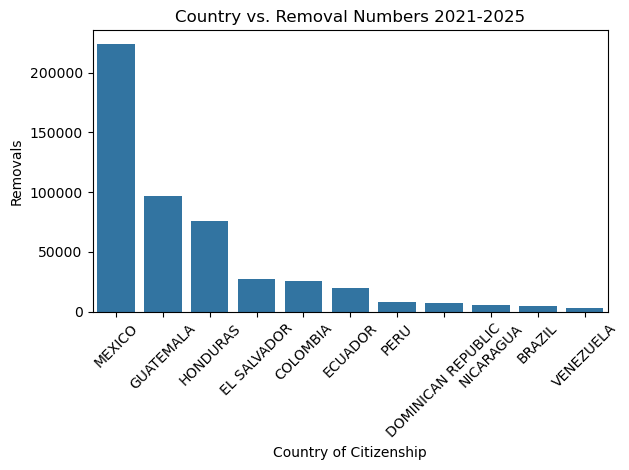

In [26]:
country_totals = df.groupby('Country of Citizenship')['Removals'].sum().reset_index()
country_totals = country_totals.sort_values('Removals', ascending=False).head(11)

sns.barplot(data=country_totals, x='Country of Citizenship', y='Removals')
plt.title('Country vs. Removal Numbers 2021-2025')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
df_TOPAOR = df[df['Area of Responsibility (AOR)'].isin(country_totals['Area of Responsibility (AOR)'])]
print(df_TOPAOR.head())

  Arresting Agency          Criminality Area of Responsibility (AOR)  \
0              CBP  Criminal Conviction                      Atlanta   
1              CBP  Criminal Conviction                      Atlanta   
2              CBP  Criminal Conviction                      Atlanta   
3              CBP  Criminal Conviction                      Atlanta   
4              CBP  Criminal Conviction                      Atlanta   

  Country of Citizenship  Fiscal Year  Fiscal Quarter  Fiscal Month  \
0            EL SALVADOR         2024               2             4   
1              GUATEMALA         2021               1             1   
2              GUATEMALA         2021               1             2   
3              GUATEMALA         2023               1             2   
4              GUATEMALA         2023               2             4   

  Month-Year  Removals  
0   Jan 2024        10  
1   Oct 2020        25  
2   Nov 2020        18  
3   Nov 2022        13  
4   Jan 2023   

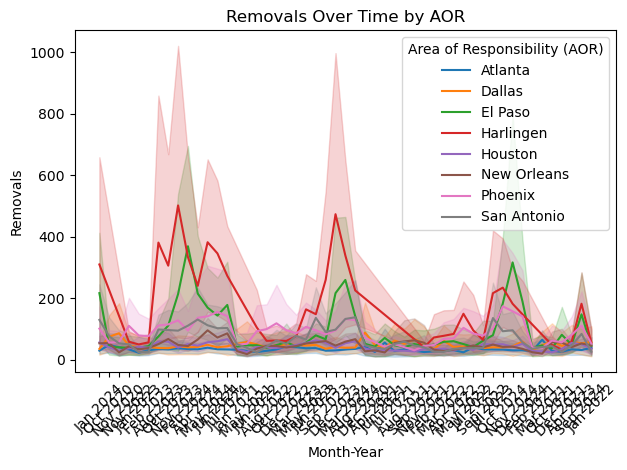

In [31]:
#Line Column for Change By Year
sns.lineplot(data=df_TOPAOR, x='Month-Year', y='Removals', hue='Area of Responsibility (AOR)')
plt.title('Removals Over Time by AOR')
plt.xlabel('Month-Year')
plt.xticks(rotation=45)
plt.ylabel('Removals')
plt.tight_layout()
plt.show()